# NOT FINISHED!!! - Parameter recocery

This notebook is a test for model fitting. Here we use agents to simulate the task, then we try to recover parameters by fitting the model to the simulated data. Model fitting is through Likelihood estimation.

This notebook can also test model comparison tools.

---
# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This notebook focuses on plotting only.
# Data is generated and saved via notebooks/behav_modeling/generate_parameter_recovery.py


In [2]:
# @title Plotting functions
...

# Section 1: Load precomputed results

Run notebooks/behav_modeling/generate_parameter_recovery.py to regenerate CSVs if needed.

In this section we load precomputed parameter recovery results from CSV files saved under results/.
Use notebooks/behav_modeling/generate_parameter_recovery.py to generate or refresh datasets.

In [3]:
import pandas as pd

# Load Foraging parameter recovery results
recovery_df = pd.read_csv('results/parameter_recovery_foraging.csv')
print(f"Loaded Foraging recovery results: {len(recovery_df)} rows")
recovery_df.head()

Loaded Foraging recovery results: 150 rows


,alpha_true,beta_true,V0_true,alpha_recovered,beta_recovered,V0_recovered,LPT_best
0,0.010530,2.999458,0.520835,0.036191,1.229257,0.378236,0.353396
1,0.315620,0.161400,0.669792,0.422668,0.010000,0.612092,0.352652
2,0.061457,5.346707,0.072086,0.065731,5.506853,0.147229,0.383647
3,0.326224,8.162802,0.115050,0.312407,9.007619,0.143383,0.720330
4,0.502402,17.176043,0.427405,0.499736,17.834441,0.427838,0.648616


In [4]:
# Display recovery results
print(f"Total simulations: {len(recovery_df)}")
print(f"\nSummary statistics:")
print(recovery_df.describe())
recovery_df


Total simulations: 150

Summary statistics:
       alpha_true   beta_true     V0_true  alpha_recovered  beta_recovered   
count  150.000000  150.000000  150.000000       150.000000      150.000000  \
mean     0.330589    6.632478    0.376210         0.300112        7.290274   
std      0.200443    7.214880    0.188716         0.188303        7.488034   
min      0.010530    0.022370    0.052713         0.010000        0.010000   
25%      0.160576    1.688306    0.203963         0.158556        2.025548   
50%      0.315825    4.375577    0.374713         0.271542        4.663670   
75%      0.506216    8.432275    0.543273         0.427999        9.511680   
max      0.697466   46.080939    0.697757         0.693633       42.803609   

       V0_recovered    LPT_best  
count    150.000000  150.000000  
mean       0.382241    0.460823  
std        0.186414    0.136263  
min        0.050000    0.348700  
25%        0.226979    0.356436  
50%        0.373060    0.384126  
75%        0.54

,alpha_true,beta_true,V0_true,alpha_recovered,beta_recovered,V0_recovered,LPT_best
0,0.010530,2.999458,0.520835,0.036191,1.229257,0.378236,0.353396
1,0.315620,0.161400,0.669792,0.422668,0.010000,0.612092,0.352652
2,0.061457,5.346707,0.072086,0.065731,5.506853,0.147229,0.383647
3,0.326224,8.162802,0.115050,0.312407,9.007619,0.143383,0.720330
4,0.502402,17.176043,0.427405,0.499736,17.834441,0.427838,0.648616
...,...,...,...,...,...,...,...
145,0.050664,1.773590,0.052713,0.505259,0.168943,0.333995,0.355754
146,0.535530,5.612852,0.261485,0.526838,5.645962,0.263377,0.525501
147,0.609801,0.387185,0.411647,0.263424,1.146721,0.421628,0.355077
148,0.590231,0.433980,0.375712,0.353562,0.673397,0.430541,0.354380


## Parameter Recovery Analysis

Visualize how well the model fitting procedure recovers the true parameters.

Filtered data: 122/150 simulations with beta < 10
Filtered data: 122/150 simulations with beta < 10


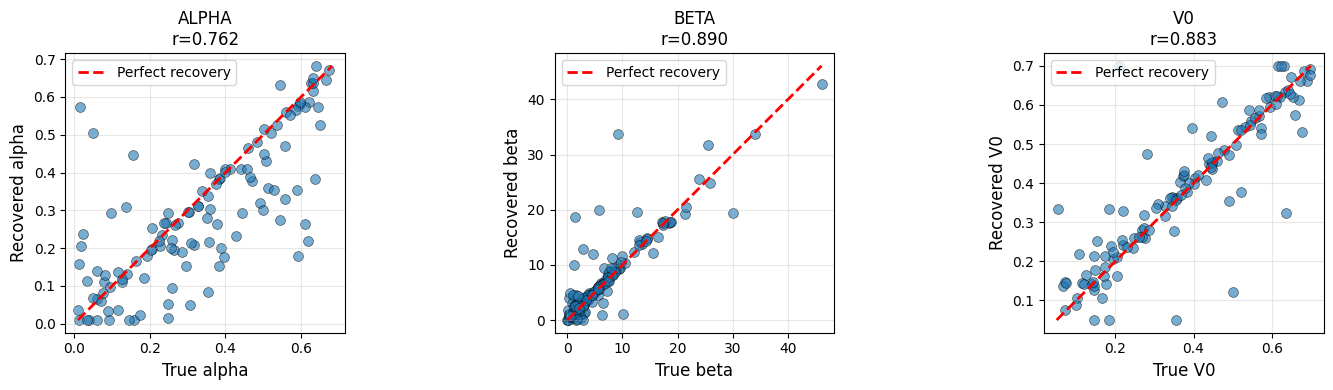

Parameter recovery correlations (beta < 10):
  alpha: r=0.762, RMSE=0.139
  beta: r=0.657, RMSE=3.538
  V0: r=0.883, RMSE=0.090


In [9]:
# Plot 1: True vs Recovered Parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


params = ['alpha', 'beta', 'V0']
for i, param in enumerate(params):
    if not param == 'beta':
        # Filter data: only include cases where beta < 10
        recovery_df_temp = recovery_df[recovery_df['beta_true'] < 10]
        print(f"Filtered data: {len(recovery_df_temp)}/{len(recovery_df)} simulations with beta < 10")
    else:
        recovery_df_temp = recovery_df

    ax = axes[i]
    
    # Scatter plot
    ax.scatter(recovery_df_temp[f'{param}_true'], recovery_df_temp[f'{param}_recovered'], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Identity line (perfect recovery)
    min_val = min(recovery_df_temp[f'{param}_true'].min(), recovery_df_temp[f'{param}_recovered'].min())
    max_val = max(recovery_df_temp[f'{param}_true'].max(), recovery_df_temp[f'{param}_recovered'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect recovery')
    
    # Calculate correlation
    corr = recovery_df_temp[f'{param}_true'].corr(recovery_df_temp[f'{param}_recovered'])
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((recovery_df_temp[f'{param}_true'] - recovery_df_temp[f'{param}_recovered'])**2))
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Recovered {param}', fontsize=12)
    ax.set_title(f'{param.upper()}\nr={corr:.3f}')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('figs/parameter_recovery_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Parameter recovery correlations (beta < 10):")
for param in params:
    corr = recovery_df_temp[f'{param}_true'].corr(recovery_df_temp[f'{param}_recovered'])
    rmse = np.sqrt(np.mean((recovery_df_temp[f'{param}_true'] - recovery_df_temp[f'{param}_recovered'])**2))
    print(f"  {param}: r={corr:.3f}, RMSE={rmse:.3f}")


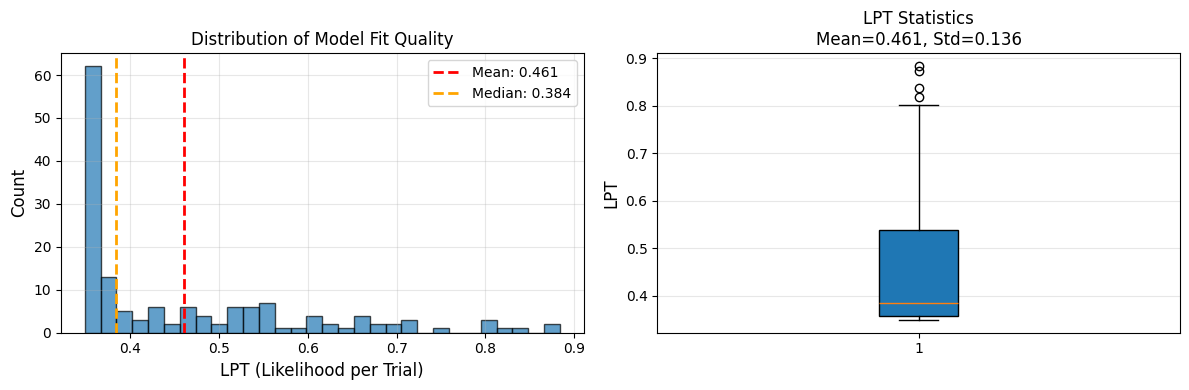

LPT Statistics:
  Mean: 0.461
  Median: 0.384
  Std: 0.136
  Min: 0.349
  Max: 0.884


In [ ]:
# Plot 2: LPT Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
ax.hist(recovery_df['LPT_best'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(recovery_df['LPT_best'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {recovery_df["LPT_best"].mean():.3f}')
ax.axvline(recovery_df['LPT_best'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {recovery_df["LPT_best"].median():.3f}')
ax.set_xlabel('LPT (Likelihood per Trial)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Model Fit Quality', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Box plot
ax = axes[1]
ax.boxplot(recovery_df['LPT_best'], vert=True, patch_artist=True)
ax.set_ylabel('LPT', fontsize=12)
ax.set_title(f'LPT Statistics\nMean={recovery_df["LPT_best"].mean():.3f}, Std={recovery_df["LPT_best"].std():.3f}', fontsize=12)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figs/parameter_recovery_lpt.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"LPT Statistics:")
print(f"  Mean: {recovery_df['LPT_best'].mean():.3f}")
print(f"  Median: {recovery_df['LPT_best'].median():.3f}")
print(f"  Std: {recovery_df['LPT_best'].std():.3f}")
print(f"  Min: {recovery_df['LPT_best'].min():.3f}")
print(f"  Max: {recovery_df['LPT_best'].max():.3f}")


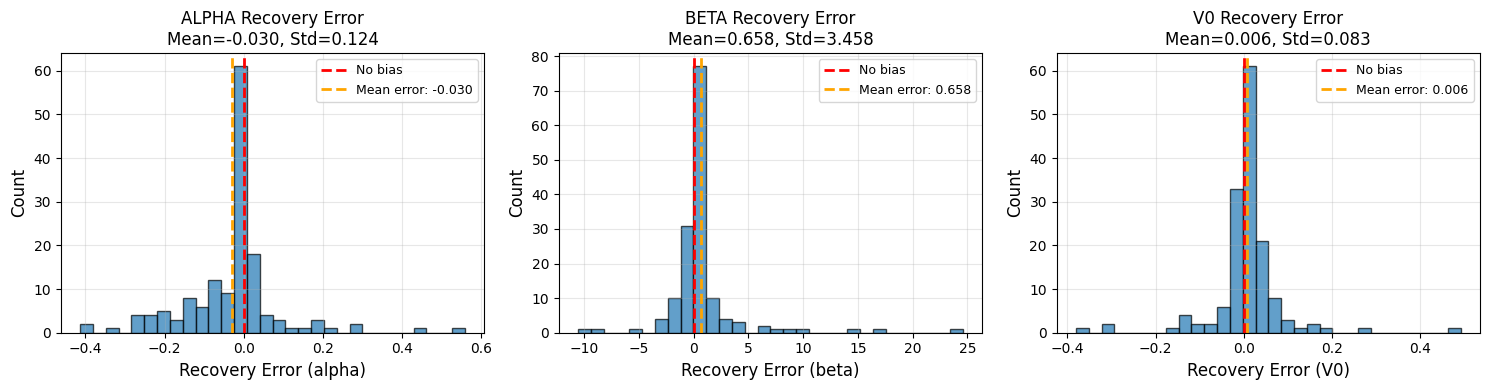


Recovery error statistics (recovered - true):
  alpha: mean=-0.030, std=0.124, median=-0.010
  beta: mean=0.658, std=3.458, median=0.234
  V0: mean=0.006, std=0.083, median=0.005


In [ ]:
# Plot 3: Recovery Error Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

params = ['alpha', 'beta', 'V0']
for i, param in enumerate(params):
    ax = axes[i]
    
    # Calculate error
    error = recovery_df[f'{param}_recovered'] - recovery_df[f'{param}_true']
    
    # Histogram of errors
    ax.hist(error, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No bias')
    ax.axvline(error.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean error: {error.mean():.3f}')
    
    ax.set_xlabel(f'Recovery Error ({param})', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{param.upper()} Recovery Error\nMean={error.mean():.3f}, Std={error.std():.3f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figs/parameter_recovery_errors.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRecovery error statistics (recovered - true):")
for param in params:
    error = recovery_df[f'{param}_recovered'] - recovery_df[f'{param}_true']
    print(f"  {param}: mean={error.mean():.3f}, std={error.std():.3f}, median={error.median():.3f}")


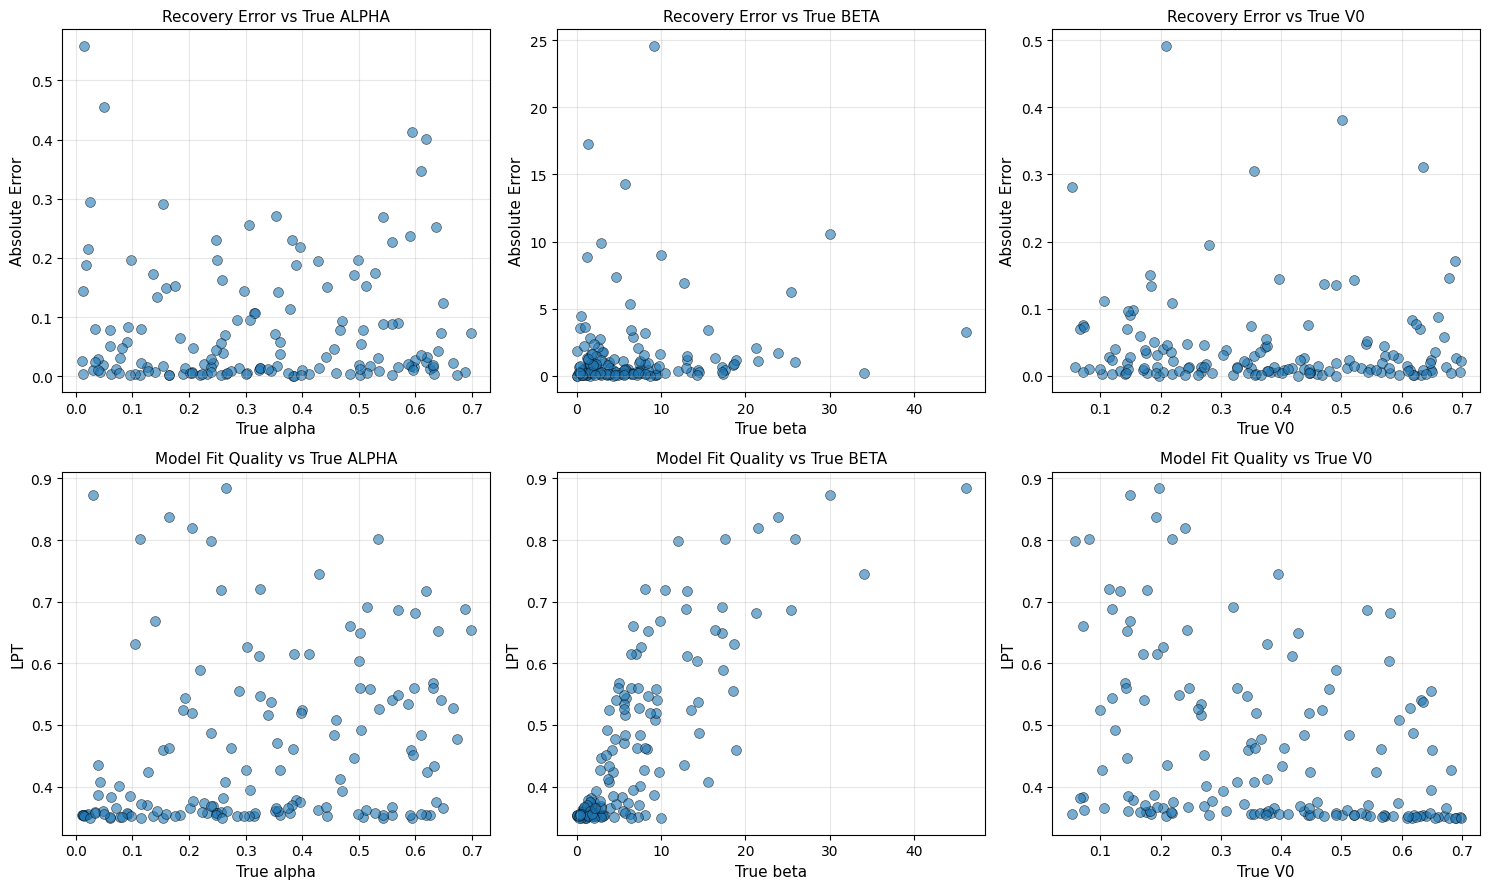

In [ ]:
# Plot 4: Recovery Performance Across Parameter Space
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

params = ['alpha', 'beta', 'V0']

# Row 1: Absolute error vs true parameter value
for i, param in enumerate(params):
    ax = axes[0, i]
    
    abs_error = np.abs(recovery_df[f'{param}_recovered'] - recovery_df[f'{param}_true'])
    
    ax.scatter(recovery_df[f'{param}_true'], abs_error, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'True {param}', fontsize=11)
    ax.set_ylabel(f'Absolute Error', fontsize=11)
    ax.set_title(f'Recovery Error vs True {param.upper()}', fontsize=11)
    ax.grid(alpha=0.3)

# Row 2: LPT vs true parameter value
for i, param in enumerate(params):
    ax = axes[1, i]
    
    ax.scatter(recovery_df[f'{param}_true'], recovery_df['LPT_best'], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'True {param}', fontsize=11)
    ax.set_ylabel(f'LPT', fontsize=11)
    ax.set_title(f'Model Fit Quality vs True {param.upper()}', fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figs/parameter_recovery_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


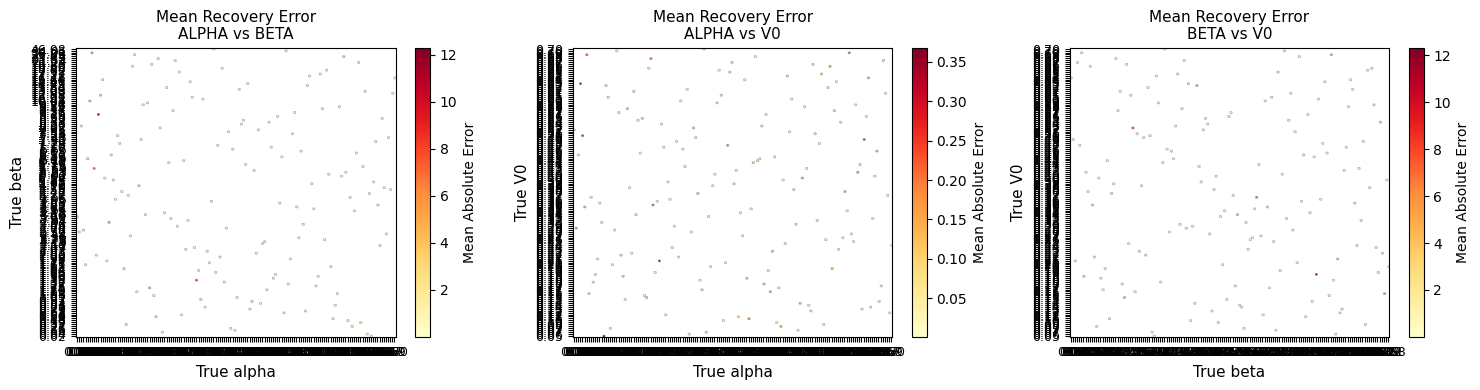

In [ ]:
# Plot 5: Heatmaps showing parameter interactions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

param_pairs = [('alpha', 'beta'), ('alpha', 'V0'), ('beta', 'V0')]

for idx, (param1, param2) in enumerate(param_pairs):
    ax = axes[idx]
    
    # Calculate average absolute error for each parameter combination
    grouped = recovery_df.groupby([f'{param1}_true', f'{param2}_true']).apply(
        lambda x: np.mean([
            np.abs(x[f'{param1}_recovered'] - x[f'{param1}_true']).values[0],
            np.abs(x[f'{param2}_recovered'] - x[f'{param2}_true']).values[0]
        ])
    ).reset_index(name='mean_abs_error')
    
    # Create pivot table for heatmap
    pivot = grouped.pivot(index=f'{param2}_true', columns=f'{param1}_true', values='mean_abs_error')
    
    # Plot heatmap
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', origin='lower')
    
    # Set ticks
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns], fontsize=9)
    ax.set_yticklabels([f'{v:.2f}' for v in pivot.index], fontsize=9)
    
    ax.set_xlabel(f'True {param1}', fontsize=11)
    ax.set_ylabel(f'True {param2}', fontsize=11)
    ax.set_title(f'Mean Recovery Error\n{param1.upper()} vs {param2.upper()}', fontsize=11)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Mean Absolute Error')

plt.tight_layout()
plt.savefig('figs/parameter_recovery_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary of Parameter Recovery Results

Key findings to interpret:

1. **Correlation & RMSE**: High correlation (r > 0.9) indicates good recovery. Low RMSE means small average errors.

2. **Recovery Bias**: Mean error near 0 indicates unbiased recovery. Systematic bias suggests the fitting procedure consistently over/underestimates.

3. **LPT Distribution**: Higher LPT = better model fit. Variability in LPT across parameter space indicates regions where the model fits better/worse.

4. **Parameter-Specific Issues**: 
   - If one parameter shows poor recovery, it may be non-identifiable or confounded with others
   - Check if errors increase at parameter boundaries (edge effects)

5. **Parameter Interactions**: Heatmaps reveal if certain parameter combinations are harder to recover (parameter confounding/trade-offs).

6. **Identifiability**: Parameters that recover well across the entire tested range are identifiable from the data.

# Section 3: Model comparison

In [ ]:
...

Ellipsis

## Inferential RL - Stickiness Parameter Recovery

Test parameter recovery for the Inferential RL model with stickiness parameter.

In [ ]:
import pandas as pd

# Load Inferential RL (stickiness) parameter recovery results
recovery_df_irl = pd.read_csv('results/parameter_recovery_inferential_rl_stickyness.csv')
print(f"Loaded IRL-stickiness recovery results: {len(recovery_df_irl)} rows")
recovery_df_irl.head()

Loaded IRL-stickiness recovery results: 125 rows


,alpha_true,beta_true,stickyness_true,alpha_recovered,beta_recovered,stickyness_recovered,LPT_best
0,0.1,2.0,0.00,0.090406,1.967118,0.000000,0.347190
1,0.1,2.0,1.25,0.155201,1.690424,1.439467,0.424107
2,0.1,2.0,2.50,0.792933,0.500000,2.618792,0.609881
3,0.1,2.0,3.75,0.288824,0.500000,4.367583,0.777947
4,0.1,2.0,5.00,0.059994,3.125469,5.366874,0.900194


In [ ]:
# Display summary statistics
print("Summary Statistics:")
print("="*60)
print(recovery_df_irl.describe())
print("\n")
print("Standard Deviations:")
for param in ['alpha', 'beta', 'stickyness']:
    print(f"  {param}: {recovery_df_irl[f'{param}_recovered'].std():.4f}")

recovery_df_irl

Summary Statistics:
       alpha_true   beta_true  stickyness_true  alpha_recovered   
count  125.000000  125.000000       125.000000       125.000000  \
mean     0.350000   11.000000         2.500000         0.352072   
std      0.177488    6.389571         1.774881         0.184018   
min      0.100000    2.000000         0.000000         0.059994   
25%      0.225000    6.500000         1.250000         0.202379   
50%      0.350000   11.000000         2.500000         0.351585   
75%      0.475000   15.500000         3.750000         0.492553   
max      0.600000   20.000000         5.000000         0.792933   

       beta_recovered  stickyness_recovered    LPT_best  
count      125.000000            125.000000  125.000000  
mean        11.242946              2.654509    0.726040  
std          6.877402              1.964301    0.125754  
min          0.500000              0.000000    0.347190  
25%          5.963747              1.232960    0.687349  
50%         11.048757       

,alpha_true,beta_true,stickyness_true,alpha_recovered,beta_recovered,stickyness_recovered,LPT_best
0,0.1,2.0,0.00,0.090406,1.967118,0.000000,0.347190
1,0.1,2.0,1.25,0.155201,1.690424,1.439467,0.424107
2,0.1,2.0,2.50,0.792933,0.500000,2.618792,0.609881
3,0.1,2.0,3.75,0.288824,0.500000,4.367583,0.777947
4,0.1,2.0,5.00,0.059994,3.125469,5.366874,0.900194
...,...,...,...,...,...,...,...
120,0.6,20.0,0.00,0.616432,19.619540,0.804940,0.814592
121,0.6,20.0,1.25,0.597243,20.733668,1.455706,0.806596
122,0.6,20.0,2.50,0.584160,22.223920,2.180551,0.799409
123,0.6,20.0,3.75,0.625159,23.890780,5.853408,0.777586


### Visualize Parameter Recovery - Inferential RL

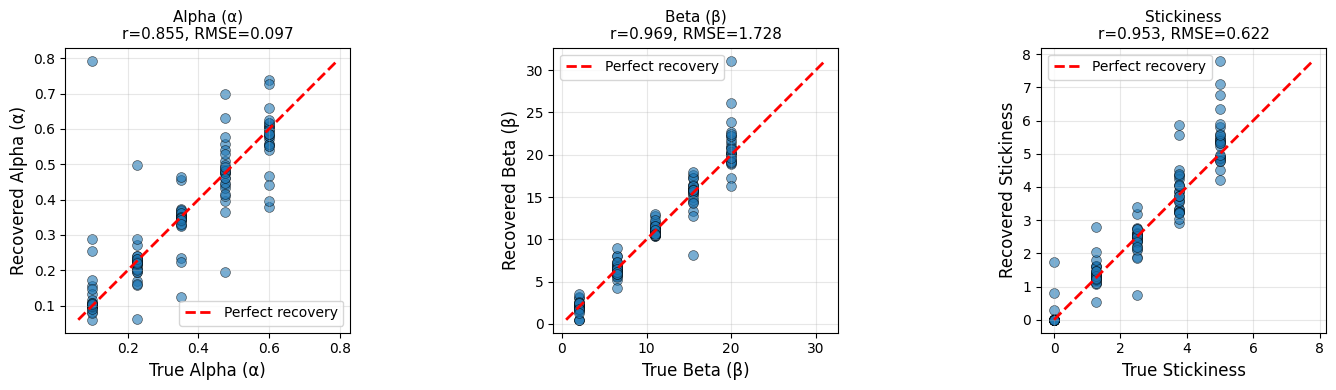

Parameter recovery correlations:
  Alpha (α): r=0.855, RMSE=0.097
  Beta (β): r=0.969, RMSE=1.728
  Stickiness: r=0.953, RMSE=0.622


In [ ]:
# Plot 1: True vs Recovered Parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

params = ['alpha', 'beta', 'stickyness']
param_labels = ['Alpha (α)', 'Beta (β)', 'Stickiness']
for i, (param, label) in enumerate(zip(params, param_labels)):
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(recovery_df_irl[f'{param}_true'], recovery_df_irl[f'{param}_recovered'], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Identity line (perfect recovery)
    min_val = min(recovery_df_irl[f'{param}_true'].min(), recovery_df_irl[f'{param}_recovered'].min())
    max_val = max(recovery_df_irl[f'{param}_true'].max(), recovery_df_irl[f'{param}_recovered'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect recovery')
    
    # Calculate correlation
    corr = recovery_df_irl[f'{param}_true'].corr(recovery_df_irl[f'{param}_recovered'])
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((recovery_df_irl[f'{param}_true'] - recovery_df_irl[f'{param}_recovered'])**2))
    
    ax.set_xlabel(f'True {label}', fontsize=12)
    ax.set_ylabel(f'Recovered {label}', fontsize=12)
    ax.set_title(f'{label}\nr={corr:.3f}, RMSE={rmse:.3f}', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('figs/parameter_recovery_irl_stickyness_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Parameter recovery correlations:")
for param, label in zip(params, param_labels):
    corr = recovery_df_irl[f'{param}_true'].corr(recovery_df_irl[f'{param}_recovered'])
    rmse = np.sqrt(np.mean((recovery_df_irl[f'{param}_true'] - recovery_df_irl[f'{param}_recovered'])**2))
    print(f"  {label}: r={corr:.3f}, RMSE={rmse:.3f}")

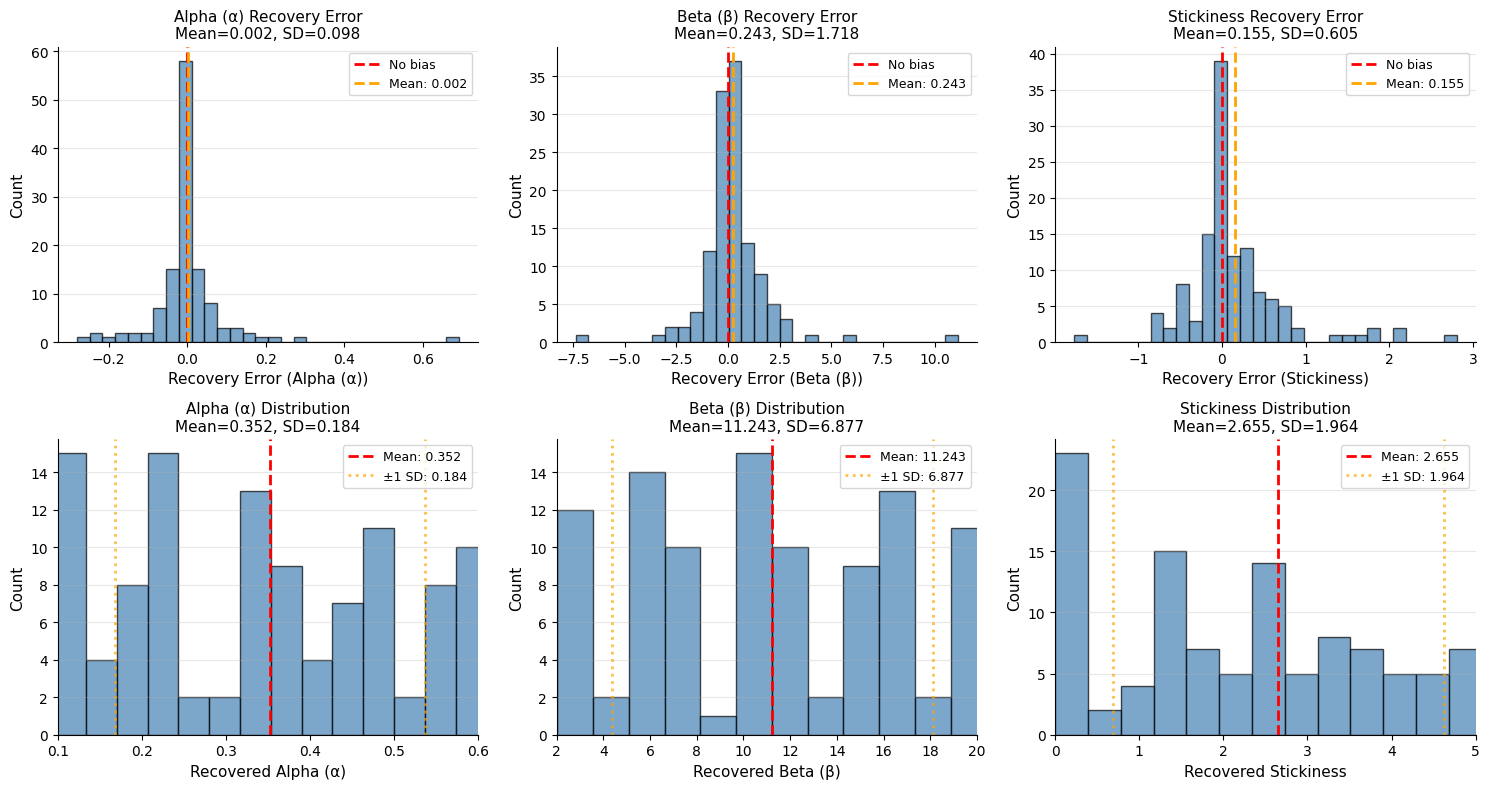


Recovery error statistics (recovered - true):
  Alpha (α): mean=0.002, std=0.098, median=-0.001
  Beta (β): mean=0.243, std=1.718, median=0.103
  Stickiness: mean=0.155, std=0.605, median=0.000


In [ ]:
# Plot 2: Parameter Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

params = ['alpha', 'beta', 'stickyness']
param_labels = ['Alpha (α)', 'Beta (β)', 'Stickiness']
param_limits = [(0.1, 0.6), (2, 20), (0, 5)]
param_ticks = [
    np.arange(0.1, 0.61, 0.1),  # alpha
    None,  # beta: default ticks
    np.arange(0, 5.1, 1)  # stickyness: 0, 1, 2, 3, 4, 5
]

for i, (param, label, xlim, xticks) in enumerate(zip(params, param_labels, param_limits, param_ticks)):
    # Recovery error distribution
    ax = axes[0, i]
    error = recovery_df_irl[f'{param}_recovered'] - recovery_df_irl[f'{param}_true']
    
    ax.hist(error, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No bias')
    ax.axvline(error.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {error.mean():.3f}')
    
    ax.set_xlabel(f'Recovery Error ({label})', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label} Recovery Error\nMean={error.mean():.3f}, SD={error.std():.3f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Recovered parameter distribution
    ax = axes[1, i]
    ax.hist(recovery_df_irl[f'{param}_recovered'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    
    mean_val = recovery_df_irl[f'{param}_recovered'].mean()
    std_val = recovery_df_irl[f'{param}_recovered'].std()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'±1 SD: {std_val:.3f}')
    
    ax.set_xlabel(f'Recovered {label}', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label} Distribution\nMean={mean_val:.3f}, SD={std_val:.3f}', fontsize=11)
    ax.set_xlim(xlim)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/parameter_recovery_irl_stickyness_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRecovery error statistics (recovered - true):")
for param, label in zip(params, param_labels):
    error = recovery_df_irl[f'{param}_recovered'] - recovery_df_irl[f'{param}_true']
    print(f"  {label}: mean={error.mean():.3f}, std={error.std():.3f}, median={error.median():.3f}")

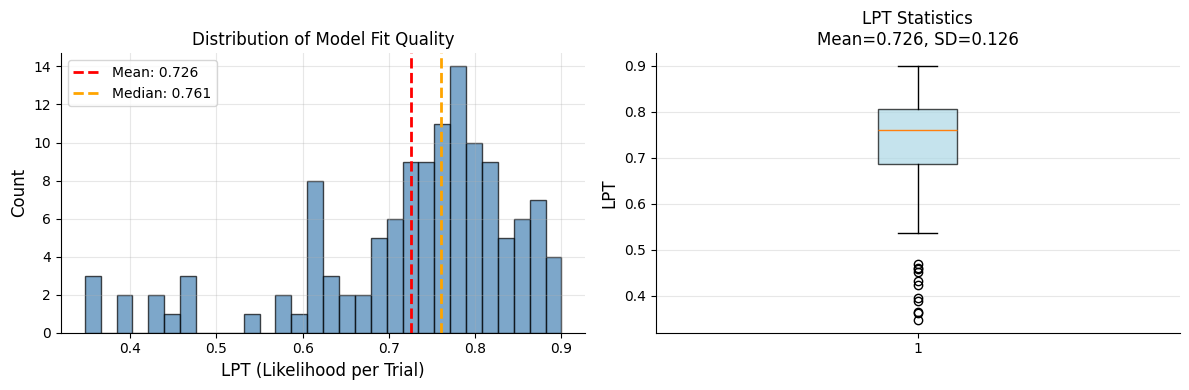

LPT Statistics:
  Mean: 0.726
  Median: 0.761
  Std: 0.126
  Min: 0.347
  Max: 0.900


In [ ]:
# Plot 3: LPT Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
ax.hist(recovery_df_irl['LPT_best'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(recovery_df_irl['LPT_best'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {recovery_df_irl["LPT_best"].mean():.3f}')
ax.axvline(recovery_df_irl['LPT_best'].median(), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {recovery_df_irl["LPT_best"].median():.3f}')
ax.set_xlabel('LPT (Likelihood per Trial)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Model Fit Quality', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Box plot
ax = axes[1]
bp = ax.boxplot(recovery_df_irl['LPT_best'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
ax.set_ylabel('LPT', fontsize=12)
ax.set_title(f'LPT Statistics\nMean={recovery_df_irl["LPT_best"].mean():.3f}, SD={recovery_df_irl["LPT_best"].std():.3f}', fontsize=12)
ax.grid(alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/parameter_recovery_irl_stickyness_lpt.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"LPT Statistics:")
print(f"  Mean: {recovery_df_irl['LPT_best'].mean():.3f}")
print(f"  Median: {recovery_df_irl['LPT_best'].median():.3f}")
print(f"  Std: {recovery_df_irl['LPT_best'].std():.3f}")
print(f"  Min: {recovery_df_irl['LPT_best'].min():.3f}")
print(f"  Max: {recovery_df_irl['LPT_best'].max():.3f}")

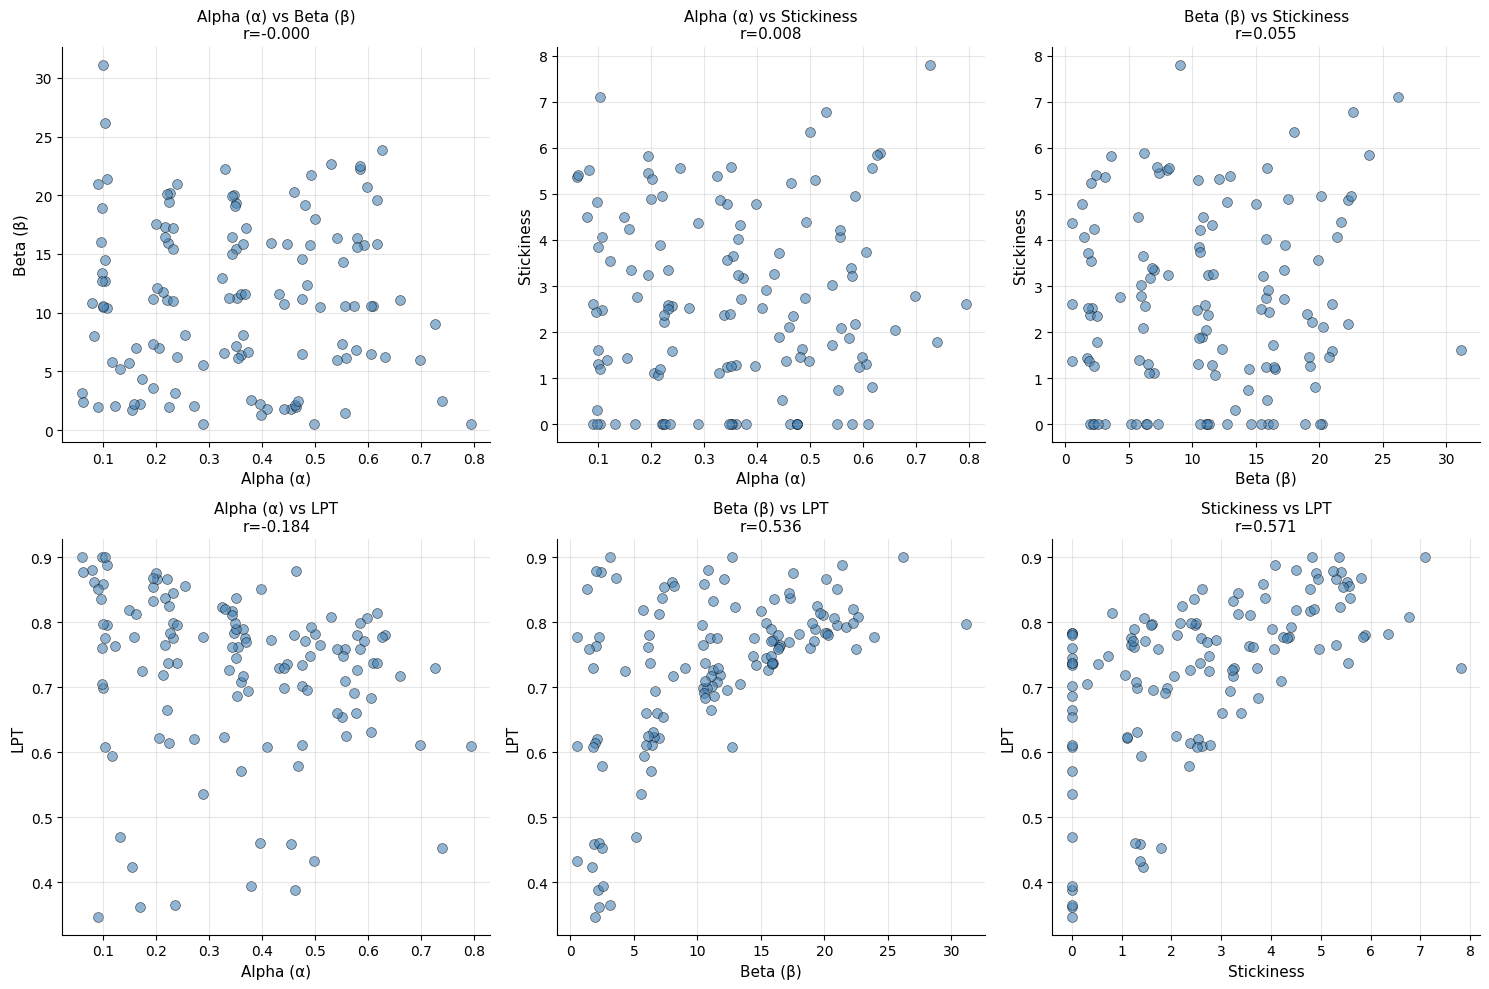


Parameter Correlations (recovered parameters):
  Alpha (α) vs Beta (β): r=-0.000
  Alpha (α) vs Stickiness: r=0.008
  Beta (β) vs Stickiness: r=0.055
  Alpha (α) vs LPT: r=-0.184
  Beta (β) vs LPT: r=0.536
  Stickiness vs LPT: r=0.571


In [ ]:
# Plot 4: Parameter Correlations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

param_pairs = [
    ('alpha', 'beta', 'Alpha (α)', 'Beta (β)'),
    ('alpha', 'stickyness', 'Alpha (α)', 'Stickiness'),
    ('beta', 'stickyness', 'Beta (β)', 'Stickiness'),
    ('alpha', 'LPT_best', 'Alpha (α)', 'LPT'),
    ('beta', 'LPT_best', 'Beta (β)', 'LPT'),
    ('stickyness', 'LPT_best', 'Stickiness', 'LPT')
]

for idx, (param1, param2, label1, label2) in enumerate(param_pairs):
    ax = axes[idx // 3, idx % 3]
    
    col1 = f'{param1}_recovered' if param1 != 'LPT_best' else 'LPT_best'
    col2 = f'{param2}_recovered' if param2 != 'LPT_best' else 'LPT_best'
    
    ax.scatter(recovery_df_irl[col1], recovery_df_irl[col2], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5, color='steelblue')
    
    # Calculate correlation
    corr = recovery_df_irl[col1].corr(recovery_df_irl[col2])
    
    ax.set_xlabel(label1, fontsize=11)
    ax.set_ylabel(label2, fontsize=11)
    ax.set_title(f'{label1} vs {label2}\nr={corr:.3f}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/parameter_recovery_irl_stickyness_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nParameter Correlations (recovered parameters):")
for param1, param2, label1, label2 in param_pairs:
    col1 = f'{param1}_recovered' if param1 != 'LPT_best' else 'LPT_best'
    col2 = f'{param2}_recovered' if param2 != 'LPT_best' else 'LPT_best'
    corr = recovery_df_irl[col1].corr(recovery_df_irl[col2])
    print(f"  {label1} vs {label2}: r={corr:.3f}")